# Прогнозирование временных рядов (Bybit): единый Jupyter pipeline

Этот ноутбук переносит текущее решение в воспроизводимый формат:
- загрузка данных BTC/ETH с основного Bybit,
- очистка и предобработка,
- запуск моделей Naive / ARIMA,
- проверки, визуализация и экспорт результатов.

## 1) Подготовка окружения и зависимостей

Если чего-то не хватает, раскомментируй установку в ячейке ниже и перезапусти kernel.

In [4]:
# При необходимости установки (раскомментируй):
# %pip install pandas numpy requests statsmodels matplotlib seaborn torch

import sys
print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорт модулей и базовые настройки

Задаём импорты, параметры отображения и конфигурацию загрузки данных.

In [5]:
from __future__ import annotations

import importlib
import pandas as pd
import seaborn as sns
from pathlib import Path

from data_pipeline import DataConfig, DataProcessor, fetch_klines, build_datasets
import model_baselines as _mb
from export_utils import plot_result, export_all_results

# В ноутбуке иногда остаётся старый кэш модуля после правок файла — принудительно обновляем
_mb = importlib.reload(_mb)
run_naive = _mb.run_naive
run_arima = _mb.run_arima
run_sarima = _mb.run_sarima
run_nbeats = _mb.run_nbeats
run_lstm = _mb.run_lstm
run_lstm_grid_search = _mb.run_lstm_grid_search
run_lstm_chunked_cv_search = _mb.run_lstm_chunked_cv_search
run_lstm_chunked_cv_pipeline = _mb.run_lstm_chunked_cv_pipeline
run_lstm_gridsearchcv_native_pipeline = _mb.run_lstm_gridsearchcv_native_pipeline
run_naive_gridsearchcv_native_pipeline = _mb.run_naive_gridsearchcv_native_pipeline
run_arima_gridsearchcv_native_pipeline = _mb.run_arima_gridsearchcv_native_pipeline
run_sarima_gridsearchcv_native_pipeline = _mb.run_sarima_gridsearchcv_native_pipeline
run_nbeats_gridsearchcv_native_pipeline = _mb.run_nbeats_gridsearchcv_native_pipeline

# Inference-only API: fit в модельных блоках, predict в weekly-блоке (#8.1).
fit_naive_inference_model = _mb.fit_naive_inference_model
predict_naive_inference = _mb.predict_naive_inference
fit_arima_inference_model = _mb.fit_arima_inference_model
predict_arima_inference = _mb.predict_arima_inference
fit_sarima_inference_model = _mb.fit_sarima_inference_model
predict_sarima_inference = _mb.predict_sarima_inference
fit_nbeats_inference_model = _mb.fit_nbeats_inference_model
predict_nbeats_inference = _mb.predict_nbeats_inference
fit_lstm_inference_model = _mb.fit_lstm_inference_model
predict_lstm_inference = _mb.predict_lstm_inference

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='60',
    bars=6000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']
OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3) Загрузка входных данных/файлов

Скачиваем свечи с Bybit API и проверяем структуру.

In [6]:
raw_data = {}
LOCAL_DATA_DIR = Path('data')
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

for symbol in SYMBOLS:
    local_file = LOCAL_DATA_DIR / f"{symbol.lower()}_timeseries.csv"
    try:
        df = fetch_klines(symbol, CONFIG)
        if df is None or len(df) == 0:
            raise RuntimeError('Bybit вернул пустой датасет')

        raw_data[symbol] = df
        df.to_csv(local_file, index=False)
        print(f"{symbol}: {len(df)} rows (скачано с API, сохранено в {local_file})")
    except Exception as e:
        if local_file.exists():
            raw_data[symbol] = pd.read_csv(local_file)
            print(f"{symbol}: API недоступен ({e}), взято локально из {local_file}, rows={len(raw_data[symbol])}")
        else:
            raise RuntimeError(
                f"{symbol}: не удалось скачать с API и нет локального файла {local_file}. Ошибка API: {e}"
            )

raw_data['BTCUSDT'].head()

BTCUSDT: 6000 rows (скачано с API, сохранено в data\btcusdt_timeseries.csv)
ETHUSDT: 6000 rows (скачано с API, сохранено в data\ethusdt_timeseries.csv)


,timestamp,open,high,low,close,volume,turnover
0,2025-07-01 05:00:00+00:00,106826.2,106908.2,106669.5,106883.0,3085.280,3.294153e+08
1,2025-07-01 06:00:00+00:00,106883.0,106883.1,106690.7,106835.7,1376.343,1.469633e+08
2,2025-07-01 07:00:00+00:00,106835.7,107126.0,106546.0,107119.9,3472.461,3.710211e+08
3,2025-07-01 08:00:00+00:00,107119.9,107119.9,106613.7,106656.9,2091.939,2.234054e+08
4,2025-07-01 09:00:00+00:00,106656.9,106730.8,106436.7,106491.1,2086.795,2.223690e+08


## 4) Очистка и предобработка данных

Убираем некорректные значения, нули и экстремальные выбросы по лог-доходности.

In [7]:
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f"{symbol}: before={rep['initial_rows']} after={rep['final_rows']} removed={rep['removed_total']} "
        f"(zero/nonpos={rep['removed_nonpositive_or_zero']}, outliers={rep['removed_outliers']})"
    )

cleaned_data['BTCUSDT'].head()

BTCUSDT: before=6000 after=5976 removed=24 (zero/nonpos=0, outliers=24)
ETHUSDT: before=6000 after=5980 removed=20 (zero/nonpos=0, outliers=20)


,timestamp,open,high,low,close,volume,turnover
0,2025-07-01 05:00:00+00:00,106826.2,106908.2,106669.5,106883.0,3085.280,3.294153e+08
1,2025-07-01 06:00:00+00:00,106883.0,106883.1,106690.7,106835.7,1376.343,1.469633e+08
2,2025-07-01 07:00:00+00:00,106835.7,107126.0,106546.0,107119.9,3472.461,3.710211e+08
3,2025-07-01 08:00:00+00:00,107119.9,107119.9,106613.7,106656.9,2091.939,2.234054e+08
4,2025-07-01 09:00:00+00:00,106656.9,106730.8,106436.7,106491.1,2086.795,2.223690e+08


## 5) Основная логика (функции и вычисления)

Разбиваем данные на train/test и реализуем запуск моделей.

In [8]:
datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f"{symbol}: full={len(data['full'])} train={len(data['train'])} test={len(data['test'])}")

BTCUSDT: full=5976 train=4780 test=1196
ETHUSDT: full=5980 train=4784 test=1196


## 6) Проверка результата и отладочные проверки

Быстрые assert-проверки целостности данных и базового запуска.

In [9]:
for symbol in SYMBOLS:
    assert symbol in datasets, f'{symbol} отсутствует в datasets'
    assert len(datasets[symbol]['train']) > 10, f'{symbol}: слишком мало train данных'
    assert len(datasets[symbol]['test']) > 10, f'{symbol}: слишком мало test данных'
    assert (datasets[symbol]['full'] > 0).all(), f'{symbol}: есть неположительные значения после очистки'

print('Базовые проверки данных пройдены.')

# smoke-test на Naive
smoke_symbol = 'BTCUSDT'
smoke_metrics, smoke_pred = run_naive(datasets[smoke_symbol]['train'], datasets[smoke_symbol]['test'])
print('Smoke Naive metrics:', smoke_metrics)
smoke_pred.head()

Базовые проверки данных пройдены.
Smoke Naive metrics: {'MAE': 299.79749163879586, 'RMSE': 444.8565429581864, 'MAPE': 0.41063572031792034}


,y_true,y_pred
0,94967.4,94969.9
1,95519.1,94967.4
2,95481.9,95519.1
3,95476.9,95481.9
4,95504.9,95476.9


## 7) Визуализация результатов

Строим график исходного ряда и сравнение факта/прогноза для выбранной модели.

In [10]:
# 1) Начальные данные
RUN_SYMBOL = 'BTCUSDT'  # BTCUSDT или ETHUSDT
ARIMA_ORDER = (1, 1, 1)
SARIMA_ORDER = (1, 1, 0)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 24)

# Глобальные флаги включения моделей
NAIVE_ENABLED = True
ARIMA_ENABLED = True
SARIMA_ENABLED = False
AST_ENABLED = False
NBEATS_ENABLED = True
LSTM_ENABLED = True

MODEL_FLAGS = {
    'naive': NAIVE_ENABLED,
    'arima': ARIMA_ENABLED,
    'sarima': SARIMA_ENABLED,
    'ast': AST_ENABLED,
    'nbeats': NBEATS_ENABLED,
    'lstm': LSTM_ENABLED,
}

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

ALL_RESULTS = {}
TRAINED_MODELS = {}

print(f'Готово к запуску моделей для {RUN_SYMBOL}')
print('Активные модели:', [m for m, enabled in MODEL_FLAGS.items() if enabled])

Готово к запуску моделей для BTCUSDT
Активные модели: ['naive', 'arima', 'nbeats', 'lstm']


NAIVE GridSearchCV: train_points=4780 | test_points=1196 | n_splits=4


NAIVE GridSearchCV:   0%|          | 0/4 [00:00<?, ?fit/s]

Fitting 4 folds for each of 1 candidates, totalling 4 fits


NAIVE GridSearchCV: 100%|██████████| 4/4 [00:03<00:00,  1.02fit/s]

NAIVE split info: {'full_points': 5976, 'train_points': 4780, 'test_points': 1196, 'test_ratio': 0.2, 'cv_n_splits': 4}
NAIVE best params: {'strategy': 'last'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000207,0.000015,0.002419,0.000052,last,{'strategy': 'last'},-258.830544,-311.5659,-367.019351,-227.398117,-291.203478,53.107923,1,291.203478,53.107923


SYMBOL=BTCUSDT | MODEL=naive
Metrics: {'MAE': 299.79749163879586, 'RMSE': 444.8565429581864, 'MAPE': 0.41063572031792034}


,y_true,y_pred
0,94967.4,94969.9
1,95519.1,94967.4
2,95481.9,95519.1
3,95476.9,95481.9
4,95504.9,95476.9


,y_true,y_pred
1191,67155.0,67227.1
1192,67257.9,67155.0
1193,66890.1,67257.9
1194,66972.2,66890.1
1195,66899.1,66972.2


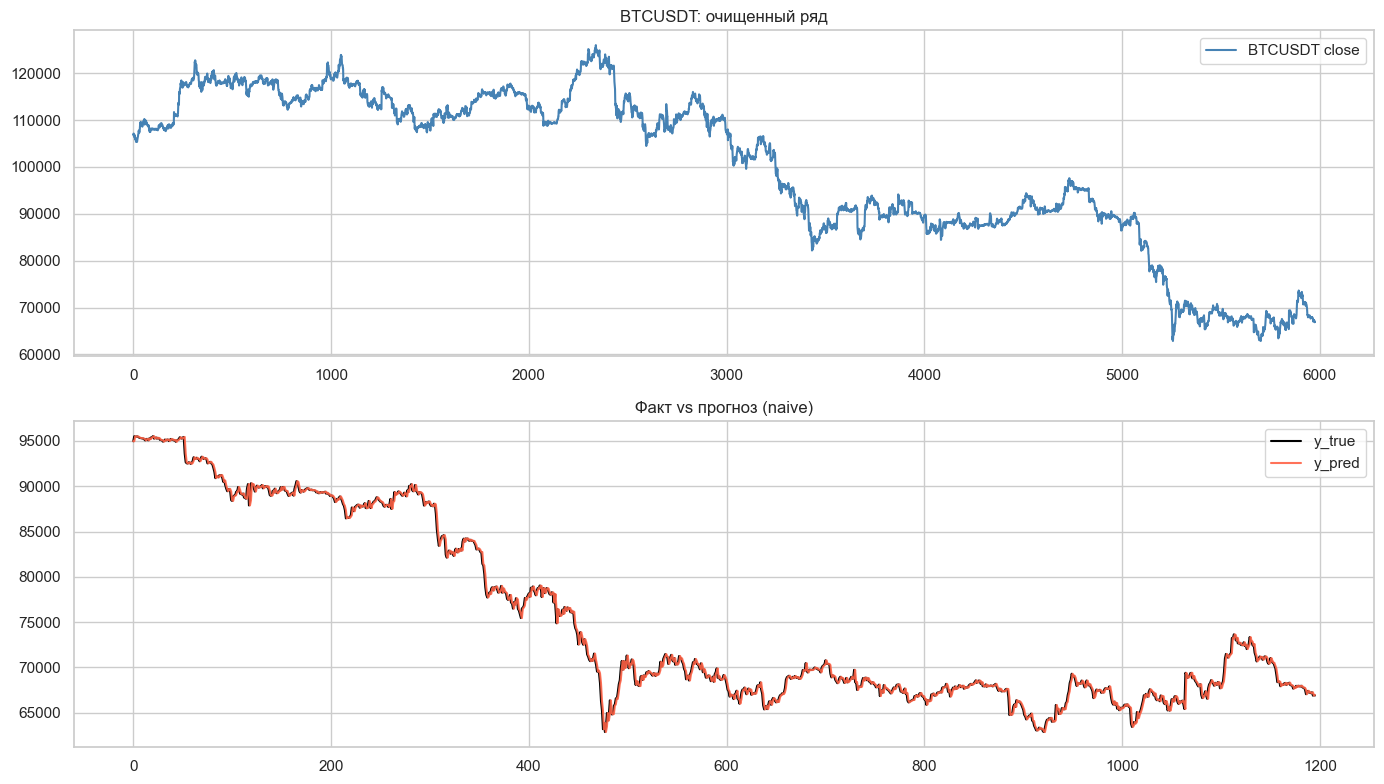

In [11]:
# 2) Модель Naive + native GridSearchCV
RUN_MODEL = 'naive'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    NAIVE_PARAM_GRID = {
        'strategy': ['last'],
    }
    NAIVE_CV_SPLITS = 4

    naive_best_params, naive_cv_df, model_metrics, pred_df, naive_split_info = run_naive_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=NAIVE_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=NAIVE_CV_SPLITS,
        scoring='MAE',
        n_jobs=32,
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_naive_inference_model(train)

    print('NAIVE split info:', naive_split_info)
    print('NAIVE best params:', naive_best_params)
    display(naive_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

ARIMA GridSearchCV: train_points=4780 | test_points=1196 | n_splits=4


ARIMA GridSearchCV:   0%|          | 0/36 [00:00<?, ?fit/s]

Fitting 4 folds for each of 9 candidates, totalling 36 fits


ARIMA GridSearchCV: 100%|██████████| 36/36 [00:34<00:00,  1.04fit/s]


ARIMA GridSearchCV: best MAE=291.074416 | order=(1, 1, 1), refit_every=24
ARIMA split info: {'full_points': 5976, 'train_points': 4780, 'test_points': 1196, 'test_ratio': 0.2, 'cv_n_splits': 4}
ARIMA best params: {'d': 1, 'p': 1, 'q': 1, 'refit_every': 24}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_d,param_p,param_q,param_refit_every,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000322,0.000017,17.931918,3.415487,1,1,1,24,"{'d': 1, 'p': 1, 'q': 1, 'refit_every': 24}",-258.118883,-311.925463,-366.959847,-227.293473,-291.074416,53.262183,1,291.074416,53.262183
1,0.000310,0.000053,21.412034,4.255846,1,1,2,24,"{'d': 1, 'p': 1, 'q': 2, 'refit_every': 24}",-257.743040,-311.969362,-366.919448,-227.738994,-291.092711,53.177586,2,291.092711,53.177586
2,0.000301,0.000027,15.262583,3.104805,1,0,1,24,"{'d': 1, 'p': 0, 'q': 1, 'refit_every': 24}",-258.353300,-311.869552,-366.821488,-227.327118,-291.092864,53.161181,3,291.092864,53.161181
3,0.000303,0.000021,16.200898,4.304356,1,1,0,24,"{'d': 1, 'p': 1, 'q': 0, 'refit_every': 24}",-258.389303,-311.863843,-366.810124,-227.325442,-291.097178,53.151538,4,291.097178,53.151538
4,0.000295,0.000023,18.957885,3.457616,1,2,0,24,"{'d': 1, 'p': 2, 'q': 0, 'refit_every': 24}",-257.858643,-311.964281,-366.927453,-227.723346,-291.118431,53.166502,5,291.118431,53.166502
5,0.000325,0.000034,21.147052,3.920337,1,0,2,24,"{'d': 1, 'p': 0, 'q': 2, 'refit_every': 24}",-257.856488,-311.983496,-366.914566,-227.728583,-291.120783,53.162568,6,291.120783,53.162568
6,0.000313,0.000029,22.367404,3.483048,1,2,2,24,"{'d': 1, 'p': 2, 'q': 2, 'refit_every': 24}",-258.113110,-311.911743,-366.846097,-227.710350,-291.145325,53.096549,7,291.145325,53.096549
7,0.000331,0.000030,15.345118,3.780978,1,0,0,24,"{'d': 1, 'p': 0, 'q': 0, 'refit_every': 24}",-258.830544,-311.565900,-367.019351,-227.398117,-291.203478,53.107923,8,291.203478,53.107923
8,0.000234,0.000011,23.693520,3.330362,1,2,1,24,"{'d': 1, 'p': 2, 'q': 1, 'refit_every': 24}",-265.754615,-476.999660,-2290.371906,-227.890013,-815.254049,856.932737,9,815.254049,856.932737


SYMBOL=BTCUSDT | MODEL=arima
Metrics: {'MAE': 299.9742627030617, 'RMSE': 444.8879097299407, 'MAPE': 0.4108937648303953}


,y_true,y_pred
0,94967.4,94969.932696
1,95519.1,94967.425629
2,95481.9,95515.807924
3,95476.9,95481.043251
4,95504.9,95476.649029


,y_true,y_pred
1191,67155.0,67225.859731
1192,67257.9,67153.203564
1193,66890.1,67258.640796
1194,66972.2,66884.559748
1195,66899.1,66970.687109


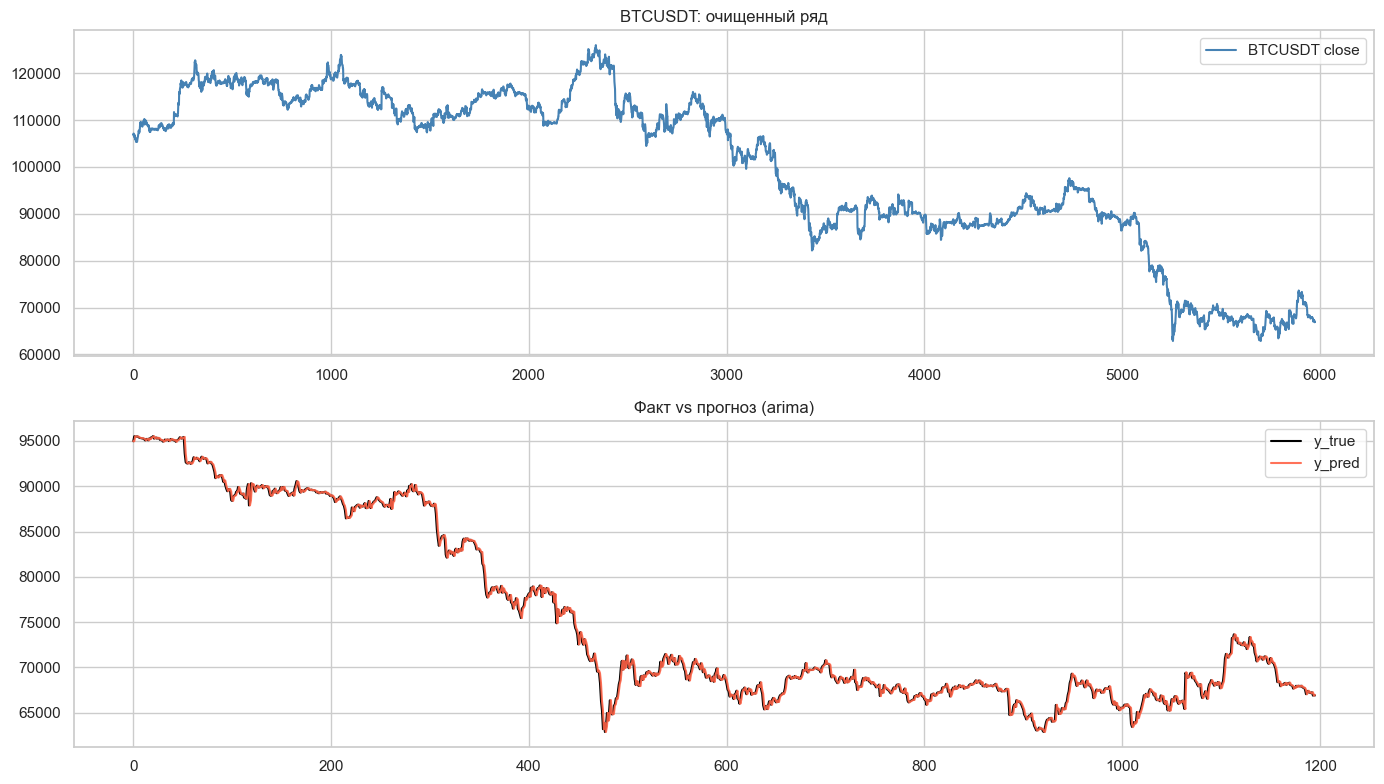

In [12]:
# 3) Модель ARIMA + native GridSearchCV
RUN_MODEL = 'arima'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    ARIMA_PARAM_GRID = {
        'p': [0, 1, 2],
        'd': [1],
        'q': [0, 1, 2],
        'refit_every': [24],
    }
    ARIMA_CV_SPLITS = 4

    arima_best_params, arima_cv_df, model_metrics, pred_df, arima_split_info = run_arima_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=ARIMA_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=ARIMA_CV_SPLITS,
        scoring='MAE',
        n_jobs=64,
    )

    ARIMA_ORDER = (
        int(arima_best_params['p']),
        int(arima_best_params['d']),
        int(arima_best_params['q']),
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_arima_inference_model(train, order=ARIMA_ORDER)

    print('ARIMA split info:', arima_split_info)
    print('ARIMA best params:', arima_best_params)
    display(arima_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [13]:
# 3.2) Модель SARIMA + native GridSearchCV
RUN_MODEL = 'sarima'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    SARIMA_PARAM_GRID = {
        'p': [1],
        'd': [1],
        'q': [0, 1],
        'sp': [1],
        'sd': [1],
        'sq': [0, 1],
        's': [24],
        'refit_every': [48],
        'fit_window': [1000],
        'maxiter': [50],
    }
    SARIMA_CV_SPLITS = 3

    sarima_best_params, sarima_cv_df, model_metrics, pred_df, sarima_split_info = run_sarima_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=SARIMA_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=SARIMA_CV_SPLITS,
        scoring='MAE',
        n_jobs=32,
    )

    SARIMA_ORDER = (
        int(sarima_best_params['p']),
        int(sarima_best_params['d']),
        int(sarima_best_params['q']),
    )
    SARIMA_SEASONAL_ORDER = (
        int(sarima_best_params['sp']),
        int(sarima_best_params['sd']),
        int(sarima_best_params['sq']),
        int(sarima_best_params['s']),
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_sarima_inference_model(
        train, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER, maxiter=50
    )

    print('SARIMA split info:', sarima_split_info)
    print('SARIMA best params:', sarima_best_params)
    display(sarima_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SKIP: sarima отключена (MODEL_FLAGS)


In [14]:
# 3.5) Модель AST + native GridSearchCV
from experiment_blocks import run_ast_astmain_style, run_ast_gridsearchcv_native_pipeline

RUN_MODEL = 'ast'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    # Подстраиваем сетку под текущую длину ряда, чтобы не падать на коротких сериях
    train_points_est = int(len(full) * (1.0 - CONFIG.test_ratio))
    max_context_allowed = max(48, train_points_est - 40)
    candidate_context = [72, 96, 120, 168]
    ast_contexts = [c for c in candidate_context if c <= max_context_allowed]
    if not ast_contexts:
        ast_contexts = [max(48, min(72, max_context_allowed))]

    # Практичная сетка для AST (умеренное число комбинаций)
    AST_PARAM_GRID = {
        'context_len': ast_contexts,
        'pred_len': [1],
        'epochs': [20],
        'batch_size': [64],
        'lr': [6e-4],
        'min_lr': [1e-5],
        'lambda_adv': [0.006, 0.008],
        'd_steps': [1],
        'd_model': [96, 128],
        'n_heads': [4, 8],
        'n_layers': [2],
        'ff_dim': [192],
        'dropout': [0.10, 0.12],
        'topk': [24],
        'use_amp': [True],
        'use_gan': ['auto'],
    }
    AST_CV_SPLITS = 3 if len(full) >= 1200 else 2

    print(f'AST auto-config: len(full)={len(full)}, context_len={ast_contexts}, cv_splits={AST_CV_SPLITS}')

    ast_best_params, ast_cv_df, model_metrics, pred_df, ast_split_info = run_ast_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=AST_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=AST_CV_SPLITS,
        scoring='MAE',
        use_cuda=True,
        n_jobs=1,
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }

    print('AST split info:', ast_split_info)
    print('AST best params:', ast_best_params)
    display(ast_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SKIP: ast отключена (MODEL_FLAGS)


NBEATS device: cpu
NBEATS GridSearch config: use_cuda=False, n_jobs=16
NBEATS GridSearchCV: train_points=4780 | test_points=1196 | n_splits=3


NBEATS GridSearchCV:   0%|          | 0/192 [00:00<?, ?fit/s]

Fitting 3 folds for each of 64 candidates, totalling 192 fits


NBEATS GridSearchCV: 100%|██████████| 192/192 [01:46<00:00,  1.80fit/s]


NBEATS GridSearchCV: best MAE=297.558592 | {'batch_size': 128, 'context_len': 168, 'epochs': 24, 'layer_size': 256, 'layers': 3, 'lr': 0.0006, 'n_blocks': 3}
NBEATS split info: {'full_points': 5976, 'train_points': 4780, 'test_points': 1196, 'test_ratio': 0.2, 'cv_n_splits': 3}
NBEATS best params: {'batch_size': 128, 'context_len': 168, 'epochs': 24, 'layer_size': 256, 'layers': 3, 'lr': 0.0006, 'n_blocks': 3}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_context_len,param_epochs,param_layer_size,param_layers,param_lr,param_n_blocks,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000595,0.000300,8.024656,3.267795,128,168,24,256,3,0.0006,3,"{'batch_size': 128, 'context_len': 168, 'epoch...",-252.596703,-391.845966,-248.233108,-297.558592,66.695037,1,297.558592,66.695037
1,0.000323,0.000035,7.405770,2.844281,128,168,16,192,4,0.0006,4,"{'batch_size': 128, 'context_len': 168, 'epoch...",-261.300720,-387.255264,-244.757267,-297.771084,63.634296,2,297.771084,63.634296
2,0.000500,0.000139,10.095187,2.676765,128,120,16,256,4,0.0006,4,"{'batch_size': 128, 'context_len': 120, 'epoch...",-270.495227,-385.837783,-241.961928,-299.431646,62.198889,3,299.431646,62.198889
3,0.000448,0.000069,5.015543,1.996190,128,168,16,192,4,0.0006,3,"{'batch_size': 128, 'context_len': 168, 'epoch...",-263.835017,-386.728788,-248.537773,-299.700526,61.854346,4,299.700526,61.854346
4,0.000339,0.000016,7.487033,3.024232,128,168,16,192,4,0.0010,4,"{'batch_size': 128, 'context_len': 168, 'epoch...",-252.003321,-405.347659,-244.407290,-300.586090,74.142496,5,300.586090,74.142496
5,0.000527,0.000124,7.973659,1.747589,128,168,24,256,4,0.0010,3,"{'batch_size': 128, 'context_len': 168, 'epoch...",-258.064091,-395.133519,-250.657909,-301.285173,66.429647,6,301.285173,66.429647
6,0.000412,0.000160,6.736544,2.082448,128,120,16,256,4,0.0010,3,"{'batch_size': 128, 'context_len': 120, 'epoch...",-271.944497,-390.077961,-242.898443,-301.640300,63.649212,7,301.640300,63.649212
7,0.000343,0.000036,9.689063,4.107019,128,120,24,192,4,0.0010,4,"{'batch_size': 128, 'context_len': 120, 'epoch...",-279.372246,-384.470471,-241.820151,-301.887623,60.373753,8,301.887623,60.373753
8,0.000751,0.000263,9.935987,3.342309,128,120,24,256,4,0.0010,3,"{'batch_size': 128, 'context_len': 120, 'epoch...",-276.027527,-382.689050,-249.020957,-302.579178,57.709227,9,302.579178,57.709227
9,0.000544,0.000235,10.267689,2.285414,128,168,24,256,4,0.0006,3,"{'batch_size': 128, 'context_len': 168, 'epoch...",-267.176168,-399.275594,-242.554504,-303.002089,68.813746,10,303.002089,68.813746


SYMBOL=BTCUSDT | MODEL=nbeats
Metrics: {'MAE': 324.4290852459946, 'RMSE': 468.31541258877877, 'MAPE': 0.44572134018610027}


,y_true,y_pred
0,94967.4,94990.597323
1,95519.1,94986.463741
2,95481.9,95534.074267
3,95476.9,95492.451401
4,95504.9,95487.344034


,y_true,y_pred
1191,67155.0,67403.846890
1192,67257.9,67323.564103
1193,66890.1,67430.605759
1194,66972.2,67053.017846
1195,66899.1,67140.103802


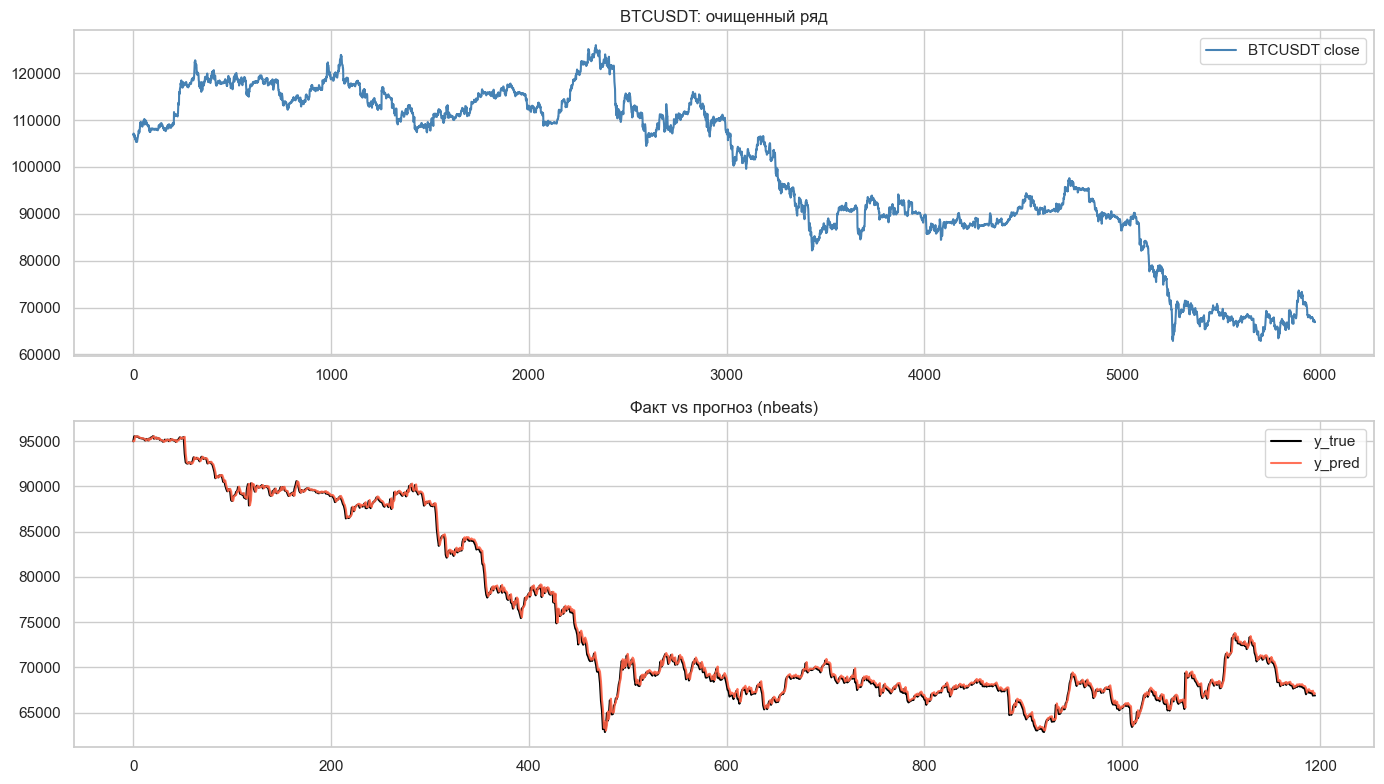

In [16]:
# 3.7) Модель N-BEATS (5-я модель) + native GridSearchCV
RUN_MODEL = 'nbeats'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    import torch

    NBEATS_USE_CUDA = False #torch.cuda.is_available()
    if NBEATS_USE_CUDA:
        print('NBEATS device:', torch.cuda.get_device_name(0))
    else:
        print('NBEATS device: cpu')

    NBEATS_PARAM_GRID = {
        'context_len': [120, 168],
        'n_blocks': [3, 4],
        'layers': [3, 4],
        'layer_size': [192, 256],
        'epochs': [16, 24],
        'batch_size': [128],
        'lr': [6e-4, 1e-3],
    }
    NBEATS_CV_SPLITS = 3

    nbeats_grid_jobs = 1 if NBEATS_USE_CUDA else 16
    print(f'NBEATS GridSearch config: use_cuda={NBEATS_USE_CUDA}, n_jobs={nbeats_grid_jobs}')

    nbeats_best_params, nbeats_cv_df, model_metrics, pred_df, nbeats_split_info = run_nbeats_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=NBEATS_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=NBEATS_CV_SPLITS,
        scoring='MAE',
        use_cuda=NBEATS_USE_CUDA,
        n_jobs=nbeats_grid_jobs,
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_nbeats_inference_model(
        train,
        context_len=int(nbeats_best_params['context_len']),
        n_blocks=int(nbeats_best_params['n_blocks']),
        layers=int(nbeats_best_params['layers']),
        layer_size=int(nbeats_best_params['layer_size']),
        epochs=int(nbeats_best_params['epochs']),
        batch_size=int(nbeats_best_params['batch_size']),
        lr=float(nbeats_best_params['lr']),
        weight_decay=float(nbeats_best_params.get('weight_decay', 1e-4)),
        use_cuda=bool(NBEATS_USE_CUDA),
    )

    print('NBEATS split info:', nbeats_split_info)
    print('NBEATS best params:', nbeats_best_params)
    display(nbeats_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

LSTM GridSearchCV: use_cuda=True, n_jobs принудительно установлен в 1 (безопасный режим для GPU).
LSTM GridSearchCV: train_points=4780 | test_points=1196 | n_splits=3


LSTM GridSearchCV: 100%|██████████| 192/192 [05:41<00:00,  1.78s/fit]


LSTM GridSearchCV: best MAE=291.338184 | {'batch_size': 32, 'context_len': 120, 'dropout': 0.05, 'epochs': 16, 'hidden_size': 96, 'lr': 0.0006, 'num_layers': 1}
LSTM device: cuda
LSTM val_loss=0.32076
LSTM val_loss=0.32076
LSTM val_loss=0.32058
LSTM val_loss=0.32029
LSTM val_loss=0.32029
LSTM val_loss=0.31981
LSTM val_loss=0.31981
LSTM val_loss=0.31981
LSTM val_loss=0.31981
LSTM val_loss=0.31948
LSTM val_loss=0.31948
LSTM val_loss=0.31948
LSTM val_loss=0.31948
LSTM val_loss=0.31948
LSTM early stop: epoch=14
LSTM split info: {'full_points': 5976, 'train_points': 4780, 'test_points': 1196, 'test_ratio': 0.2, 'cv_n_splits': 3}
LSTM best params: {'batch_size': 32, 'context_len': 120, 'dropout': 0.05, 'epochs': 16, 'hidden_size': 96, 'lr': 0.0006, 'num_layers': 1}

Топ комбинаций по GridSearchCV:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_context_len,param_dropout,param_epochs,param_hidden_size,param_lr,param_num_layers,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000128,0.000042,1.615346,0.881617,32,120,0.05,16,96,0.0006,1,"{'batch_size': 32, 'context_len': 120, 'dropou...",-248.914154,-383.374546,-241.725853,-291.338184,65.145666,1,291.338184,65.145666
1,0.000122,0.000015,1.369341,0.592944,32,72,0.05,16,96,0.0010,2,"{'batch_size': 32, 'context_len': 72, 'dropout...",-249.156559,-383.026798,-241.880755,-291.354704,64.889978,2,291.354704,64.889978
2,0.000119,0.000018,1.024462,0.296036,32,72,0.00,16,96,0.0010,1,"{'batch_size': 32, 'context_len': 72, 'dropout...",-248.899687,-383.477620,-241.731992,-291.369767,65.195790,3,291.369767,65.195790
3,0.000113,0.000009,1.239901,0.451894,32,120,0.05,24,96,0.0010,1,"{'batch_size': 32, 'context_len': 120, 'dropou...",-249.097800,-383.237719,-241.799165,-291.378228,65.022776,4,291.378228,65.022776
4,0.000106,0.000011,1.683492,0.659977,32,72,0.05,24,128,0.0010,1,"{'batch_size': 32, 'context_len': 72, 'dropout...",-249.127445,-383.328454,-241.721173,-291.392357,65.078914,5,291.392357,65.078914
5,0.000112,0.000007,1.908403,0.976251,32,120,0.05,24,96,0.0010,2,"{'batch_size': 32, 'context_len': 120, 'dropou...",-249.215456,-383.224212,-241.746603,-291.395423,65.004311,6,291.395423,65.004311
6,0.000111,0.000009,1.004102,0.323982,32,120,0.00,16,96,0.0006,1,"{'batch_size': 32, 'context_len': 120, 'dropou...",-249.219805,-383.299946,-241.674576,-291.398109,65.057376,7,291.398109,65.057376
7,0.000127,0.000011,1.442574,0.889703,32,120,0.05,16,96,0.0010,1,"{'batch_size': 32, 'context_len': 120, 'dropou...",-248.955838,-383.326038,-241.918826,-291.400234,65.064813,8,291.400234,65.064813
8,0.000123,0.000005,1.370497,0.380952,32,120,0.05,16,96,0.0010,2,"{'batch_size': 32, 'context_len': 120, 'dropou...",-249.063387,-383.315956,-241.857280,-291.412208,65.052318,9,291.412208,65.052318
9,0.000130,0.000018,1.885587,0.702017,32,120,0.00,24,128,0.0006,1,"{'batch_size': 32, 'context_len': 120, 'dropou...",-249.057153,-383.338464,-241.881393,-291.425670,65.058149,10,291.425670,65.058149


SYMBOL=BTCUSDT | MODEL=lstm
Metrics: {'MAE': 298.9669535413961, 'RMSE': 444.5499687101007, 'MAPE': 0.4095070385841267}


,y_true,y_pred
0,94967.4,94977.516571
1,95519.1,94974.546264
2,95481.9,95503.632429
3,95476.9,95481.663371
4,95504.9,95478.274731


,y_true,y_pred
1191,67155.0,67233.586306
1192,67257.9,67162.174951
1193,66890.1,67258.641662
1194,66972.2,66904.445897
1195,66899.1,66973.354691


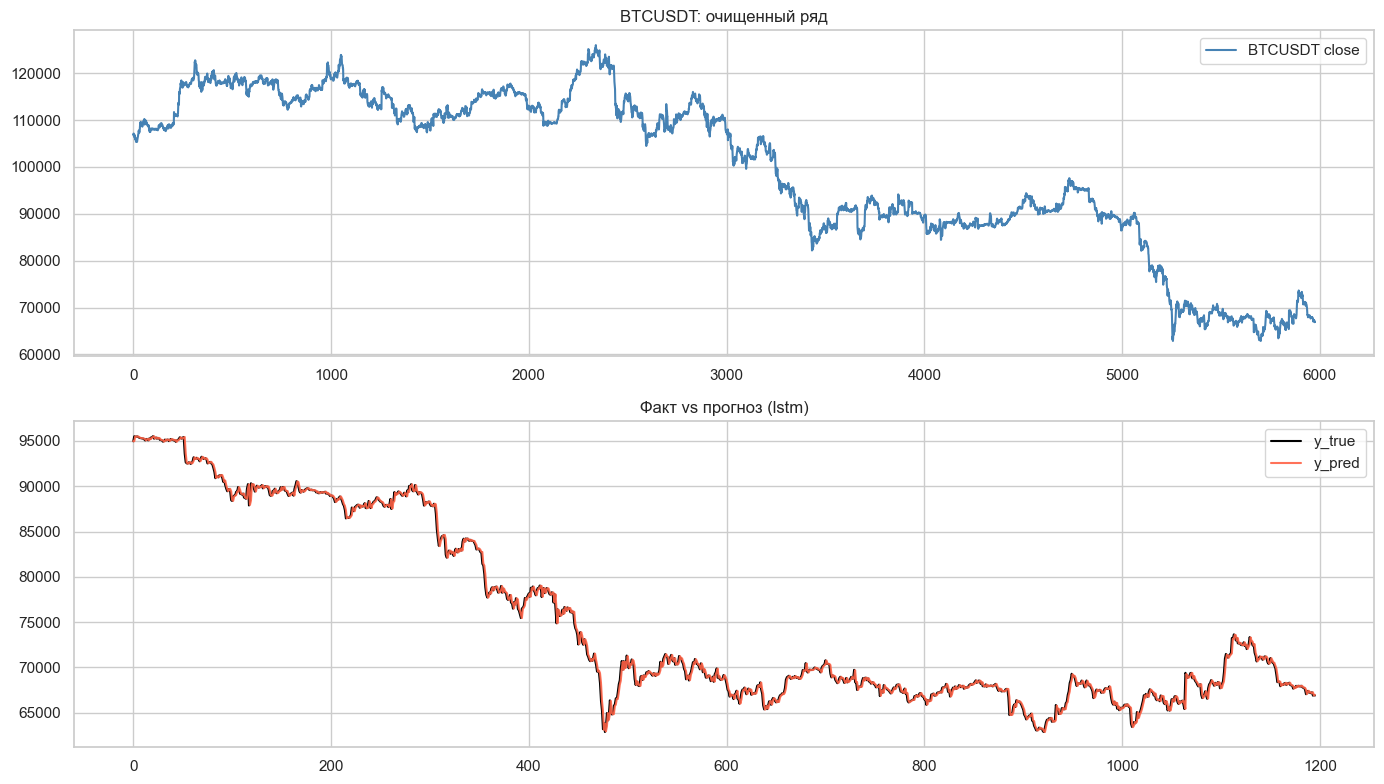

In [17]:
# 3.9) Модель LSTM (6-я модель) + native sklearn GridSearchCV
RUN_MODEL = 'lstm'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    LSTM_SCORING = 'MAE'
    LSTM_GRID_N_JOBS = 16  # для одной GPU безопасно оставлять 1
    LSTM_CV_SPLITS = 3

    # GridSearchCV перебирает все комбинации (ParameterGrid)
    LSTM_PARAM_GRID = {
        'context_len': [72, 120],
        'hidden_size': [96, 128],
        'num_layers': [1, 2],
        'dropout': [0.0, 0.05],
        'epochs': [16, 24],
        'batch_size': [32],
        'lr': [6e-4, 1e-3],
    }

    best_params, lstm_cv_df, model_metrics, pred_df, split_info = run_lstm_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=LSTM_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=LSTM_CV_SPLITS,
        scoring=LSTM_SCORING,
        use_cuda=True,
        n_jobs=LSTM_GRID_N_JOBS,
    )

    print('LSTM split info:', split_info)
    print('LSTM best params:', best_params)
    print('\nТоп комбинаций по GridSearchCV:')
    display(lstm_cv_df.head(20))

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_lstm_inference_model(
        train,
        context_len=int(best_params['context_len']),
        hidden_size=int(best_params['hidden_size']),
        num_layers=int(best_params['num_layers']),
        dropout=float(best_params['dropout']),
        epochs=int(best_params['epochs']),
        batch_size=int(best_params['batch_size']),
        lr=float(best_params['lr']),
        weight_decay=float(best_params.get('weight_decay', 1e-4)),
        use_cuda=True,
    )

    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [ ]:
# 8.1) 100 случайных недельных датасетов с Bybit: inference-only тест уже обученных моделей (многопоток)
import numpy as np
import pandas as pd
import importlib
import time
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import experiment_blocks as _exp

_exp = importlib.reload(_exp)

N_WEEKS_REQUESTED = 100
ENABLED_MODELS = [m for m, enabled in MODEL_FLAGS.items() if enabled]
WEEK_HOURS = 7 * 24
MAX_FETCH_ATTEMPTS_PER_WEEK = 20
MAX_RANDOM_YEARS_BACK = 4

CPU_COUNT = int(os.cpu_count() or 8)
PARALLEL_WORKERS = 32

if len(ENABLED_MODELS) == 0:
    raise RuntimeError('Все модели отключены в MODEL_FLAGS. Включи хотя бы одну модель для #8.1.')

if 'TRAINED_MODELS' not in globals() or not isinstance(TRAINED_MODELS, dict):
    raise RuntimeError('TRAINED_MODELS не найден. Сначала запусти модельные ячейки 2-3.9, чтобы обучить и сохранить модели.')

missing_trained = [m for m in ENABLED_MODELS if m not in TRAINED_MODELS and m != 'ast']
if missing_trained:
    raise RuntimeError(f'Нет обученных моделей для inference-only weekly: {missing_trained}. Перезапусти соответствующие модельные ячейки.')

if 'ast' in ENABLED_MODELS:
    print('ВНИМАНИЕ: AST в #8.1 inference-only пока не поддержан и будет пропущен.')
    ENABLED_MODELS = [m for m in ENABLED_MODELS if m != 'ast']

if len(ENABLED_MODELS) == 0:
    raise RuntimeError('После фильтрации не осталось моделей для #8.1.')

# История нужна только для autoregressive inference (NBEATS/LSTM), без обучения.
HISTORY_SERIES_FOR_INFERENCE = datasets[RUN_SYMBOL]['train'].astype(float).reset_index(drop=True)
if len(HISTORY_SERIES_FOR_INFERENCE) < 80:
    raise RuntimeError(f'Слишком короткая история для inference: {len(HISTORY_SERIES_FOR_INFERENCE)}')

print(f'Параллельный режим #8.1: workers={PARALLEL_WORKERS}, cpu_count={CPU_COUNT}')

def _evaluate_week(week_idx: int):
    week_raw = pd.DataFrame()
    picked_start = None
    picked_end = None

    for _attempt in range(1, MAX_FETCH_ATTEMPTS_PER_WEEK + 1):
        try:
            candidate = _exp._fetch_week_by_random_end(
                base_url=CONFIG.base_url,
                symbol=RUN_SYMBOL,
                interval=CONFIG.interval,
                week_hours=WEEK_HOURS,
                max_years_back=MAX_RANDOM_YEARS_BACK,
            )
            if len(candidate) < WEEK_HOURS:
                continue

            ts_min = candidate['timestamp'].min()
            ts_max = candidate['timestamp'].max()
            if pd.isna(ts_min) or pd.isna(ts_max):
                continue

            week_raw = candidate.iloc[-WEEK_HOURS:].copy().reset_index(drop=True)
            picked_start = week_raw['timestamp'].min()
            picked_end = week_raw['timestamp'].max()
            break
        except Exception:
            continue

    if len(week_raw) < WEEK_HOURS:
        return {
            'week': week_idx + 1,
            'rows': [],
            'info': None,
            'message': f'Week {week_idx + 1}: пропуск, не удалось скачать валидный недельный датасет',
        }

    chunk_clean, _ = processor.process(week_raw)
    test_week = chunk_clean[CONFIG.target_col].astype(float).reset_index(drop=True)

    if len(test_week) < 24:
        return {
            'week': week_idx + 1,
            'rows': [],
            'info': None,
            'message': f'Week {week_idx + 1}: пропуск, недостаточно точек test={len(test_week)}',
        }

    info = {
        'week': week_idx + 1,
        'start_ts': picked_start,
        'end_ts': picked_end,
        'raw_points': int(len(week_raw)),
        'clean_points': int(len(test_week)),
    }

    rows = []
    for model_name in ENABLED_MODELS:
        t0 = time.perf_counter()
        try:
            if model_name == 'naive':
                m, _pred = predict_naive_inference(TRAINED_MODELS['naive'], test_week)
            elif model_name == 'arima':
                m, _pred = predict_arima_inference(TRAINED_MODELS['arima'], test_week)
            elif model_name == 'sarima':
                m, _pred = predict_sarima_inference(TRAINED_MODELS['sarima'], test_week)
            elif model_name == 'nbeats':
                m, _pred = predict_nbeats_inference(TRAINED_MODELS['nbeats'], HISTORY_SERIES_FOR_INFERENCE, test_week)
            elif model_name == 'lstm':
                m, _pred = predict_lstm_inference(TRAINED_MODELS['lstm'], HISTORY_SERIES_FOR_INFERENCE, test_week)
            else:
                continue

            elapsed_sec = float(time.perf_counter() - t0)
            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(test_week)),
                'MAE': float(m['MAE']),
                'RMSE': float(m['RMSE']),
                'MAPE': float(m['MAPE']),
                'duration_sec': elapsed_sec,
            })
        except Exception as ex:
            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(test_week)),
                'MAE': np.nan,
                'RMSE': np.nan,
                'MAPE': np.nan,
                'duration_sec': np.nan,
                'error': str(ex),
            })

    message = (
        f"Week {week_idx + 1}/{N_WEEKS_REQUESTED}: {picked_start} .. {picked_end} "
        f"| test={len(test_week)} | trained_models=inference_only"
    )

    return {'week': week_idx + 1, 'rows': rows, 'info': info, 'message': message}

results = []
if PARALLEL_WORKERS > 1:
    with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
        futures = {executor.submit(_evaluate_week, i): i for i in range(N_WEEKS_REQUESTED)}
        for future in as_completed(futures):
            results.append(future.result())
else:
    for i in range(N_WEEKS_REQUESTED):
        results.append(_evaluate_week(i))

weekly_rows = []
weeks_info = []
for result in sorted(results, key=lambda r: r['week']):
    if result.get('message'):
        print(result['message'])
    if result.get('info') is not None:
        weeks_info.append(result['info'])
    weekly_rows.extend(result.get('rows', []))

weekly_metrics_df = pd.DataFrame(weekly_rows)
weeks_info_df = pd.DataFrame(weeks_info)

if len(weekly_metrics_df) == 0:
    raise RuntimeError('Не удалось собрать weekly-метрики. Проверь доступ к API и обученные модели.')

summary = (
    weekly_metrics_df.groupby('model', as_index=False)[['MAE', 'RMSE', 'MAPE']]
    .mean()
    .sort_values('MAE')
    .reset_index(drop=True)
)

weekly_ts = pd.Timestamp.utcnow().strftime('%Y%m%d_%H%M%S')
weekly_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_metrics_{weekly_ts}.csv"
summary_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_summary_{weekly_ts}.csv"
weeks_info_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_weeks_{weekly_ts}.csv"

weekly_metrics_df.to_csv(weekly_path, index=False)
summary.to_csv(summary_path, index=False)
weeks_info_df.to_csv(weeks_info_path, index=False)

def _weekly_with_score(df: pd.DataFrame, metric_col: str = 'MAE'):
    work = (
        df.copy()
        .sort_values(['week', metric_col, 'model'], na_position='last')
        .reset_index(drop=True)
    )

    if 'duration_sec' not in work.columns:
        work['duration_sec'] = np.nan

    work['color_tag'] = 'orange'
    work['score'] = 1

    for _week_value, idxs in work.groupby('week', sort=True).groups.items():
        week_rows = work.loc[list(idxs)]
        valid = week_rows[week_rows[metric_col].notna()].sort_values(metric_col)
        if len(valid) == 0:
            continue

        best_metric = float(valid.iloc[0][metric_col])
        ranked_indices = list(valid.index)

        for rank_pos, ridx in enumerate(ranked_indices, start=1):
            cur_metric = float(work.loc[ridx, metric_col])
            worse_ratio = (cur_metric / best_metric) if best_metric > 1e-12 else np.inf

            if worse_ratio >= 2.0:
                work.loc[ridx, 'color_tag'] = 'red'
                work.loc[ridx, 'score'] = 0
            elif rank_pos == 1:
                work.loc[ridx, 'color_tag'] = 'green'
                work.loc[ridx, 'score'] = 3
            elif worse_ratio <= 1.10:
                work.loc[ridx, 'color_tag'] = 'yellow'
                work.loc[ridx, 'score'] = 2
            else:
                work.loc[ridx, 'color_tag'] = 'orange'
                work.loc[ridx, 'score'] = 1

        for ridx in week_rows.index:
            if pd.isna(work.loc[ridx, metric_col]):
                work.loc[ridx, 'color_tag'] = 'gray'
                work.loc[ridx, 'score'] = 0

    return work

def _weekly_style_with_dividers(scored_df: pd.DataFrame):
    row_styles = {i: '' for i in scored_df.index}
    color_map = {
        'green': 'background-color: #7CFC00; color: black',
        'yellow': 'background-color: #FFD700; color: black',
        'orange': 'background-color: #FFA500; color: black',
        'red': 'background-color: #ff6b6b; color: black',
        'gray': 'background-color: #D3D3D3; color: black',
    }

    def _append_style(base: str, extra: str) -> str:
        base = (base or '').strip()
        if not base:
            return extra
        if base.endswith(';'):
            return f"{base} {extra}"
        return f"{base}; {extra}"

    for idx, row in scored_df.iterrows():
        row_styles[idx] = _append_style(row_styles[idx], color_map.get(row['color_tag'], ''))

    for _week_value, idxs in scored_df.groupby('week', sort=True).groups.items():
        last_idx = int(max(idxs))
        row_styles[last_idx] = _append_style(
            row_styles.get(last_idx, ''),
            'border-bottom: 3px solid #444'
        )

    return scored_df.style.apply(
        lambda row: [row_styles.get(row.name, '') for _ in row.index],
        axis=1,
    )

def _build_model_ranking(scored_df: pd.DataFrame, summary_df: pd.DataFrame):
    rank_input = scored_df.copy()
    rank_input['green_count'] = (rank_input['color_tag'] == 'green').astype(int)
    rank_input['red_count'] = (rank_input['color_tag'] == 'red').astype(int)

    rank_df = (
        rank_input.groupby('model', as_index=False)
        .agg(
            points=('score', 'sum'),
            green_count=('green_count', 'sum'),
            red_count=('red_count', 'sum'),
            avg_duration_sec=('duration_sec', 'mean'),
            total_duration_sec=('duration_sec', 'sum'),
            weeks_count=('week', 'nunique'),
        )
        .sort_values(['points', 'green_count', 'red_count', 'avg_duration_sec'], ascending=[False, False, True, True])
        .reset_index(drop=True)
    )

    summary_plus = summary_df.merge(rank_df, on='model', how='left')
    return rank_df, summary_plus

scored_weekly_df = _weekly_with_score(weekly_metrics_df, metric_col='MAE')
styled_weekly = _weekly_style_with_dividers(scored_weekly_df)
model_ranking_df, summary_with_rank_df = _build_model_ranking(scored_weekly_df, summary)

max_points = int(N_WEEKS_REQUESTED * 3)

print('\nСохранено:')
print(weekly_path.resolve())
print(summary_path.resolve())
print(weeks_info_path.resolve())
print('Активные модели для #8.1:', ENABLED_MODELS)
print('Режим #8.1: INFERENCE-ONLY (без обучения на weekly)')
print('History length for autoregressive inference:', len(HISTORY_SERIES_FOR_INFERENCE))
print('\nЛегенда цветов (по каждой неделе, метрика MAE):')
print('лучшая | в пределах +10% от лучшей | остальные | хуже лучшей на 100%+')
print('Границы между пятерками моделей выделены толстой линией.')
print('Баллы: red=0, orange=1, yellow=2, green=3')
print(f'Итог по {N_WEEKS_REQUESTED} неделям: 0 = очень плохо, {max_points} = очень хорошо')

print('\nВыбранные случайные недели:')
display(weeks_info_df)

print('\nWeekly-детализация (цветовая + баллы):')
display(styled_weekly)

print('\nРейтинг моделей по баллам:')
display(model_ranking_df)

print('\nСредние метрики + баллы + время обучения:')
display(summary_with_rank_df)

Параллельный режим #8.1: workers=2, cpu_count=32, cuda_inference=True


## 9) Сохранение артефактов и экспорт

Сохраняем предсказания и метрики, чтобы можно было быстро сравнивать запуски.

In [ ]:
symbol_for_save = RUN_SYMBOL if 'RUN_SYMBOL' in globals() else 'UNKNOWN'

if 'ALL_RESULTS' not in globals() or len(ALL_RESULTS) == 0:
    raise RuntimeError('Нет результатов. Сначала запусти модельные ячейки naive, arima, sarima, ast, nbeats, lstm.')

# Подхватываем последний запуск модели, если она еще не в реестре
if 'RUN_MODEL' in globals() and 'model_metrics' in globals() and 'pred_df' in globals() and RUN_MODEL not in ALL_RESULTS:
    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': symbol_for_save,
    }

run_dir, metrics_path, metrics_df = export_all_results(
    output_dir=OUTPUT_DIR,
    symbol=symbol_for_save,
    full_series=full,
    all_results=ALL_RESULTS,
)

print('Сохранено:')
print(run_dir.resolve())
print(metrics_path.resolve())
print('\nСводная таблица метрик:')
display(metrics_df)

enabled_list = [m for m, enabled in MODEL_FLAGS.items() if enabled] if 'MODEL_FLAGS' in globals() else ['naive', 'arima', 'sarima', 'ast', 'nbeats', 'lstm']
missing_models = [m for m in enabled_list if m not in ALL_RESULTS]
if missing_models:
    print(f"\nНе хватает результатов включенных моделей: {missing_models}. Запусти соответствующие модельные ячейки.")

Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260308_042356
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260308_042356\BTCUSDT_all_models_metrics.csv

Сводная таблица метрик:


,symbol,model,MAE,RMSE,MAPE
0,BTCUSDT,naive,299.785786,444.854804,0.410618
1,BTCUSDT,arima,299.785786,444.854804,0.410618



Не хватает результатов включенных моделей: ['nbeats', 'lstm']. Запусти соответствующие модельные ячейки.


In [ ]:
import importlib, model_baselines, inspect
print('module file:', model_baselines.__file__)
print('has run_sarima:', hasattr(model_baselines, 'run_sarima'))
print('symbols:', [s for s in dir(model_baselines) if s.startswith('run_')])
importlib.reload(model_baselines)
print('after reload has run_sarima:', hasattr(model_baselines, 'run_sarima'))

module file: c:\Users\zzz20\ModelLine\model_baselines.py
has run_sarima: True
symbols: ['run_arima', 'run_arima_gridsearchcv_native_pipeline', 'run_lstm', 'run_lstm_chunked_cv_pipeline', 'run_lstm_chunked_cv_search', 'run_lstm_grid_search', 'run_lstm_gridsearchcv_native_pipeline', 'run_naive', 'run_naive_gridsearchcv_native_pipeline', 'run_nbeats', 'run_nbeats_gridsearchcv_native_pipeline', 'run_sarima', 'run_sarima_gridsearchcv_native_pipeline']
after reload has run_sarima: True
